In [9]:
import os
import matplotlib.pyplot as plt
from glob import glob as gg
from keras.models import Model
from collections import Counter
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, max, min, udf
from pyspark.sql.types import StructField, StructType, StringType, ArrayType, IntegerType, FloatType

In [ ]:
spark = SparkSession.builder \
            .appName("LSTMJsonExtractor") \
            .config("spark.driver.port", "5432") \
            .config("spark.blockManager.port", "4321") \
            .config("spark.driver.memory", "16g") \
            .config("spark.executor.memory", "16g") \
            .config("spark.driver.maxResultSize", "16g") \
            .getOrCreate()

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/04/25 11:26:32 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


----------------------------------------
Exception occurred during processing of request from ('127.0.0.1', 32876)
Traceback (most recent call last):
  File "/home2/va23abb/miniconda3/envs/myenv/lib/python3.9/socketserver.py", line 316, in _handle_request_noblock
    self.process_request(request, client_address)
  File "/home2/va23abb/miniconda3/envs/myenv/lib/python3.9/socketserver.py", line 347, in process_request
    self.finish_request(request, client_address)
  File "/home2/va23abb/miniconda3/envs/myenv/lib/python3.9/socketserver.py", line 360, in finish_request
    self.RequestHandlerClass(request, client_address, self)
  File "/home2/va23abb/miniconda3/envs/myenv/lib/python3.9/socketserver.py", line 747, in __init__
    self.handle()
  File "/home2/va23abb/miniconda3/envs/myenv/lib/python3.9/site-packages/pyspark/accumulators.py", line 295, in handle
    poll(accum_updates)
  File "/home2/va23abb/miniconda3/envs/myenv/lib/python3.9/site-packages/pyspark/accumulators.py", line 26

In [3]:
## Local
# archive = "archive"

# Cluster
archive = "/home2/va23abb/.cache/kagglehub/datasets/aidapearson/ocr-data/versions/36"

In [4]:
images_dir = f"{archive}/batch_*/background_images/*.jpg"
json_dir = f"{archive}/batch_*/JSON/*"

image_paths = gg(f"{images_dir}")
json_paths = gg(f"{json_dir}")

lookup_dict = {os.path.basename(path): path for path in image_paths}
broadcast_lookup = spark.sparkContext.broadcast(lookup_dict)
lookup_udf = udf(lambda fn: broadcast_lookup.value.get(fn), StringType())

In [10]:
image_data_schema = StructType([
    StructField("full_latex_chars", StringType(), True),
    StructField("visible_latex_chars", ArrayType(StringType()), True),
    StructField("visible_char_map",    ArrayType(IntegerType()), True),
    StructField("width",  FloatType(), True),
    StructField("height", FloatType(), True),
    StructField("depth",  FloatType(), True),
    StructField("xmins",  ArrayType(FloatType()), True),
    StructField("xmaxs",  ArrayType(FloatType()), True),
    StructField("ymins",  ArrayType(FloatType()), True),
    StructField("ymaxs",  ArrayType(FloatType()), True),
    StructField("xmins_raw", ArrayType(IntegerType()), True),
    StructField("xmaxs_raw", ArrayType(IntegerType()), True),
    StructField("ymins_raw", ArrayType(IntegerType()), True),
    StructField("ymaxs_raw", ArrayType(IntegerType()), True),
    StructField("png_masks",  ArrayType(StringType()), True),
])

In [15]:
full_schema = StructType([
    StructField("filename", StringType(), True),
    StructField("latex",    StringType(), True),
    StructField("image_data", image_data_schema, True),
])

In [16]:
images_df_0 = spark.read.json(json_paths[0], schema = full_schema)

images_df_0.show(5)

+--------------------+--------------------+--------------------+
|            filename|               latex|          image_data|
+--------------------+--------------------+--------------------+
|bd85ee85-2549-453...|\lim_{a\to\frac{\...|{["\\lim_","{","a...|
|e97b0b1f-08bf-4c2...|\lim_{w\to\pi/5^{...|{["\\lim_","{","w...|
|3c72e1a1-c1de-4d6...|e^{\lim_{b\to4^{+...|{["e","^","{","\\...|
|54459370-7cbe-423...|\lim_{\theta\to\p...|{["\\lim_","{","\...|
|da71ce9d-e1a1-4bb...|=\lim_{x\to8^{+}}...|{["=","\\lim_","{...|
+--------------------+--------------------+--------------------+
only showing top 5 rows



In [7]:
images_df = spark.createDataFrame([], schema = spark.read.json(json_paths[0]).schema)

for path in json_paths[1:]:
    temp_df = spark.read.json(path)
    images_df = images_df.union(temp_df)

images_exp = images_df.withColumn("filename", col("filename").cast(StringType())). \
                        withColumn("latex", col("latex").cast(StringType())). \
                        withColumn("full_latex_chars", col("image_data.full_latex_chars").cast(StringType())). \
                        withColumn("visible_latex_chars", col("image_data.visible_latex_chars").cast(ArrayType(StringType()))). \
                        withColumn("visible_char_map", col("image_data.visible_char_map").cast(ArrayType(IntegerType()))). \
                        withColumn("width", col("image_data.width").cast(FloatType())). \
                        withColumn("height", col("image_data.height").cast(FloatType())). \
                        withColumn("depth", col("image_data.depth").cast(FloatType())). \
                        withColumn("xmins", col("image_data.xmins").cast(ArrayType(FloatType()))). \
                        withColumn("xmaxs", col("image_data.xmaxs").cast(ArrayType(FloatType()))). \
                        withColumn("ymins", col("image_data.ymins").cast(ArrayType(FloatType()))). \
                        withColumn("ymaxs", col("image_data.ymaxs").cast(ArrayType(FloatType()))). \
                        withColumn("xmins_raw", col("image_data.xmins_raw").cast(ArrayType(IntegerType()))). \
                        withColumn("xmaxs_raw", col("image_data.xmaxs_raw").cast(ArrayType(IntegerType()))). \
                        withColumn("ymins_raw", col("image_data.ymins_raw").cast(ArrayType(IntegerType()))). \
                        withColumn("ymaxs_raw", col("image_data.ymaxs_raw").cast(ArrayType(IntegerType()))). \
                        withColumn("true_file_paths", lookup_udf(col("filename"))). \
                        withColumn("png_masks", col("image_data.png_masks").cast(ArrayType(StringType())))

images_red = images_exp.drop("font", "image_data", "unicode_less_curlies", "unicode_str", "uuid")


In [17]:
images_red.show(5)

+--------------------+--------------------+--------------------+--------------------+--------------------+------+------+-----+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+
|            filename|               latex|    full_latex_chars| visible_latex_chars|    visible_char_map| width|height|depth|               xmins|               xmaxs|               ymins|               ymaxs|           xmins_raw|           xmaxs_raw|           ymins_raw|           ymaxs_raw|     true_file_paths|           png_masks|
+--------------------+--------------------+--------------------+--------------------+--------------------+------+------+-----+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+-----------

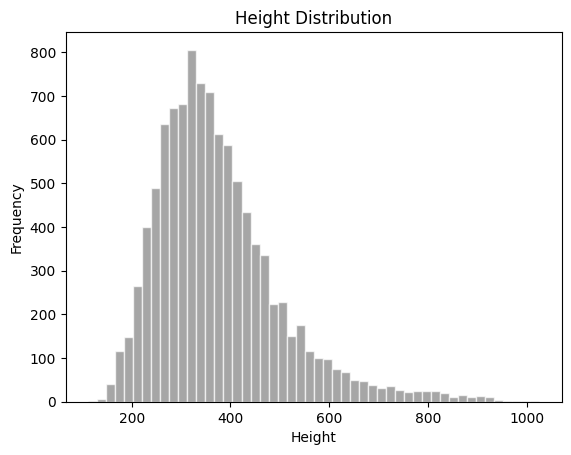

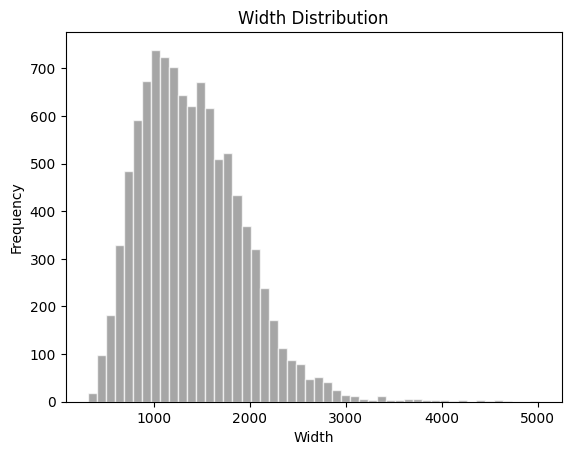

In [12]:
# Exploration of the DataFrame

# Height distribution
sample_fraction = 0.1
heights = images_exp.select("height") \
                  .sample(fraction = sample_fraction, seed = 42) \
                  .toPandas()["height"]
plt.hist(heights, bins = 50, edgecolor = "white", color = 'gray', alpha = 0.7)
plt.title("Height Distribution")
plt.xlabel("Height")
plt.ylabel("Frequency")
plt.show()

# Width distribution
widths = images_exp.select("width"). \
                    sample(fraction = sample_fraction, seed = 42). \
                    toPandas()["width"]
plt.hist(widths, bins = 50, edgecolor = "white", color = 'gray', alpha = 0.7)
plt.title("Width Distribution")
plt.xlabel("Width")
plt.ylabel("Frequency")
plt.show()

In [42]:
visible_latex = images_exp.select("visible_latex_chars").sample(fraction = 0.1, seed = 42).toPandas()

all_visible_chars = [
    token
    for arr in visible_latex["visible_latex_chars"]
    for token in arr
]

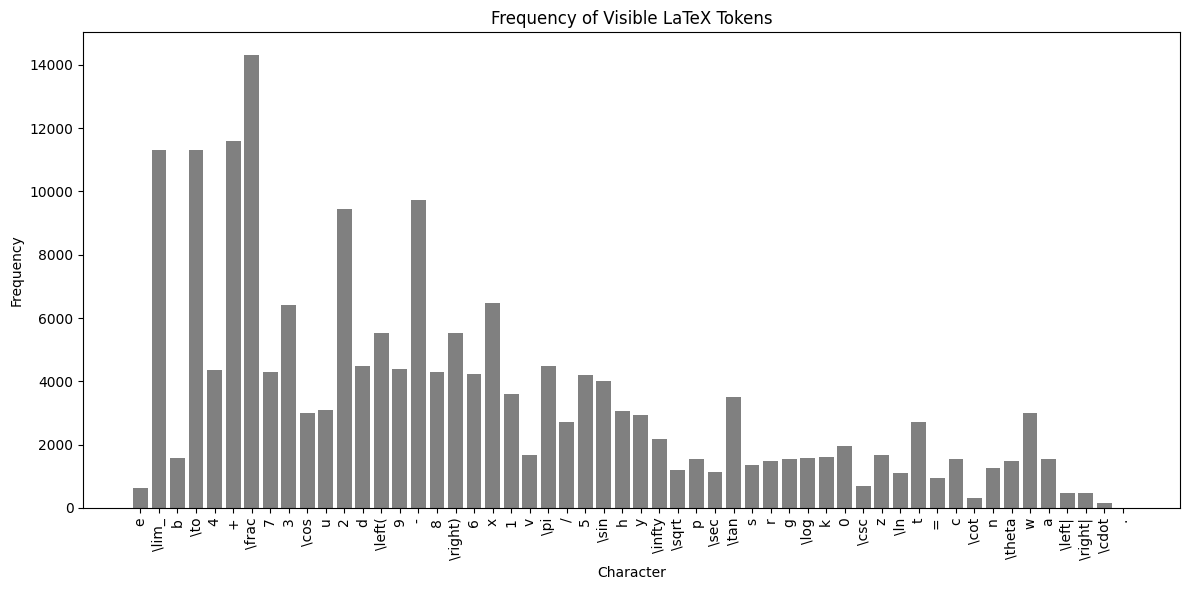

In [43]:
char_count = Counter(all_visible_chars)

chars = list(char_count.keys())
counts = list(char_count.values())

plt.figure(figsize = (12, 6))
plt.bar(chars, counts, color = "gray")
plt.xticks(rotation = 90)
plt.xlabel("Character")
plt.ylabel("Frequency")
plt.title("Frequency of Visible LaTeX Tokens")
plt.tight_layout()
plt.show()

In [ ]:
all_labels_df_small = images_exp.select("full_latex_chars").sample(fraction = 0.001, seed = 42).toPandas()

In [ ]:
all_labels_df = images_exp.select("full_latex_chars").sample(fraction = 0.001, seed = 42).toPandas()

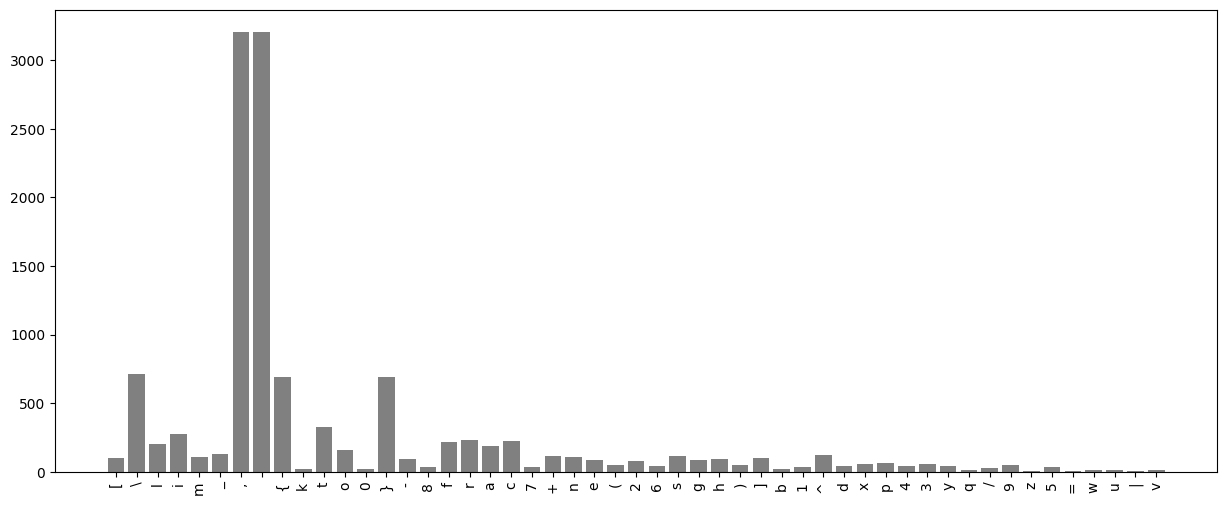

In [36]:
all_labels = [
    token
    for arr in all_labels_df["full_latex_chars"]
    for token in arr
]

label_count = Counter(all_labels)

lab_keys = label_count.keys()
lab_vals = label_count.values()

plt.figure(figsize = (15, 6))
plt.bar(lab_keys, lab_vals, color = "gray")
plt.xticks(rotation = 90)
plt.show()

In [35]:
new_label_count = label_count.pop(",")
new_label_count = new_label_count.pop(" ")

# lab_keys = new_label_count.keys()
# lab_vals = new_label_count.values()

# plt.figure(figsize = (15, 6))
# plt.bar(lab_keys, lab_vals, color = "gray")
# plt.xticks(rotation = 90)
# plt.show()

label_count[","]

0

In [15]:
all_labels[:5]

['[', '\\', 'l', 'i', 'm']

In [ ]:
images_exp.show(3)

In [ ]:
max_width = images_red.agg(max("width")).collect()[0][0]
min_width = images_red.agg(min("width")).collect()[0][0]
max_height = images_red.agg(max("height")).collect()[0][0]
min_height = images_red.agg(min("height")).collect()[0][0]
print(f"Max height: {max_height} \nMin height: {min_height} \nMax width: {max_width} \nMin width: {min_width}")

ConnectionRefusedError: [Errno 111] Connection refused

In [7]:
# 1197.0 100.0 5340.0 259.0

In [18]:
images_small_dims = images_red.filter((col("width") <= 1000) & (col("height") <= 300))

In [19]:
images_small_dims.select("width", "height").show(5)
# print(images_small_dims.count())

+-----+------+
|width|height|
+-----+------+
|833.0| 239.0|
|730.0| 148.0|
|707.0| 294.0|
|787.0| 298.0|
|375.0| 215.0|
+-----+------+
only showing top 5 rows



In [10]:
# feature_model = load_model('models/symbol_model.keras')

In [11]:
# normalizing image inputs to the model

In [20]:
images_small_dims.coalesce(1).write.parquet("images_small_dims.parquet")
# images_small_dims.coalesce(1).write.format("parquet").save("data/images_small_dims.parquet")

In [12]:
temp = spark.read.parquet("images_small_dims.parquet")

temp.show(5)

+--------------------+--------------------+--------------------+--------------------+--------------------+-----+------+-----+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+
|            filename|               latex|    full_latex_chars| visible_latex_chars|    visible_char_map|width|height|depth|               xmins|               xmaxs|               ymins|               ymaxs|           xmins_raw|           xmaxs_raw|           ymins_raw|           ymaxs_raw|     true_file_paths|           png_masks|
+--------------------+--------------------+--------------------+--------------------+--------------------+-----+------+-----+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------